In [2]:
# load necessary libraries and disable some warnings
import json
import ast
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import numpy as np
import sys
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
from transformers import AutoTokenizer
import torch
import umap
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, normalized_mutual_info_score, adjusted_rand_score
from pathlib import Path

project_root = Path.cwd() / "../"
sys.path.append(str(project_root))

from utils.preprocessing import create_category_regex, match_dictionary
from utils.clustering import ModelMask, get_mask_embedding

# load the dictionary terms
groups_dict_wide = pd.read_csv("../01_data/classification/dictionary/groups_dictionary_cl.csv")

## **Prepare Data, Load and Apply Model to Dictionary**

In [4]:
# create lists for all dictionary entries and their category names
mention_list = []
category_list = []
categories = groups_dict_wide.columns
cat2id = {c: i for i, c in enumerate(categories)}
for category in categories:
    for idx, row in groups_dict_wide[[category]].iterrows():
        if not pd.isna(row.values):
            entry = row.values[0]
            mention_list.append(entry.strip())
            category_list.append(category)
category_list = [cat for cat in category_list]

# create long df based on these lists
groups_dict_long = pd.DataFrame({'mention': mention_list, 'category': category_list})

# load model from checkpoint
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
model = ModelMask(tokenizer).to(device)
model.load_state_dict(torch.load(f="model_checkpoint/checkpoint.pt", map_location=torch.device("mps")))

# apply model to all dictionary entries
dictionary_embeddings = get_mask_embedding(model, mention_list, tokenizer, device)
dictionary_labels_np = np.array([cat2id[cat] for cat in category_list])

## **Visualize Clusters Without and With Contrastive Finetuning**

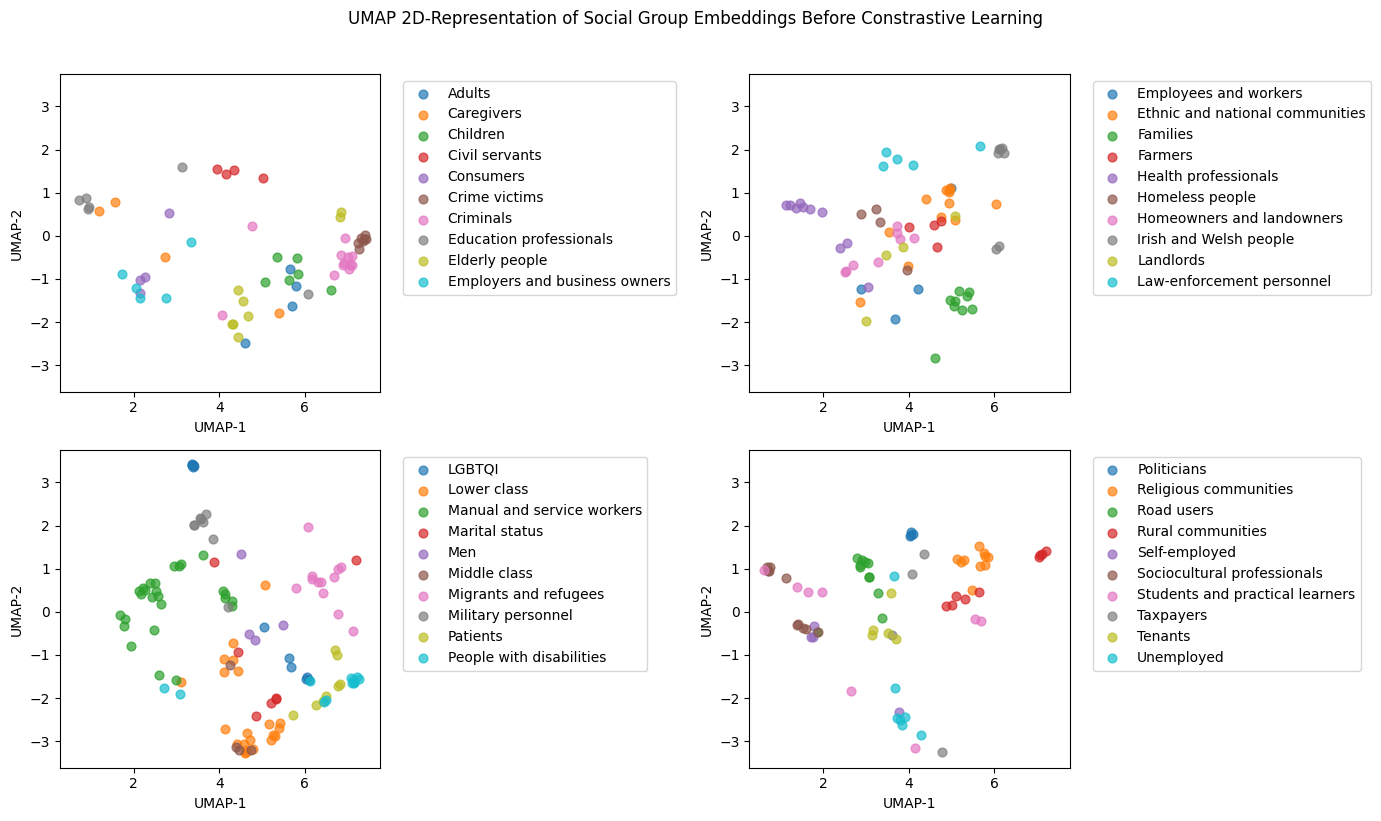

In [8]:
# create a fresh model instance and get embeddings from this model
model_without_cl = ModelMask(tokenizer).to(device)
emb_without_cl = get_mask_embedding(model_without_cl, mention_list, tokenizer, device)

# initialize umap reducer and apply to the embeddings
reducer = umap.UMAP(n_components=2)
emb_2d = reducer.fit_transform(emb_without_cl)

# get axis ranges
x_min, x_max = emb_2d[:, 0].min(), emb_2d[:, 0].max()
y_min, y_max = emb_2d[:, 1].min(), emb_2d[:, 1].max()
pad = 0.05
x_range = x_max - x_min
y_range = y_max - y_min

# get all unique categories as a list and the total number of categories
categories = list(cat2id.keys())
num_classes = len(categories)

# define groups to plot
groups = [
    range(0, 10),
    range(10, 20),
    range(20, 30),
    range(30, 40)
]

# draw the 2x2 plot with categories as colored labels
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, group in zip(axes, groups):
    for c in group:
        idx = np.where(dictionary_labels_np == c)[0]
        ax.scatter(
            emb_2d[idx, 0],
            emb_2d[idx, 1],
            label=categories[c],
            alpha=0.7,
            s=40
        )
    ax.set_xlim(x_min - pad * x_range, x_max + pad * x_range)
    ax.set_ylim(y_min - pad * y_range, y_max + pad * y_range)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

fig.suptitle("UMAP 2D-Representation of Social Group Embeddings Before Constrastive Learning", y=1.02)
plt.tight_layout()
plt.show()

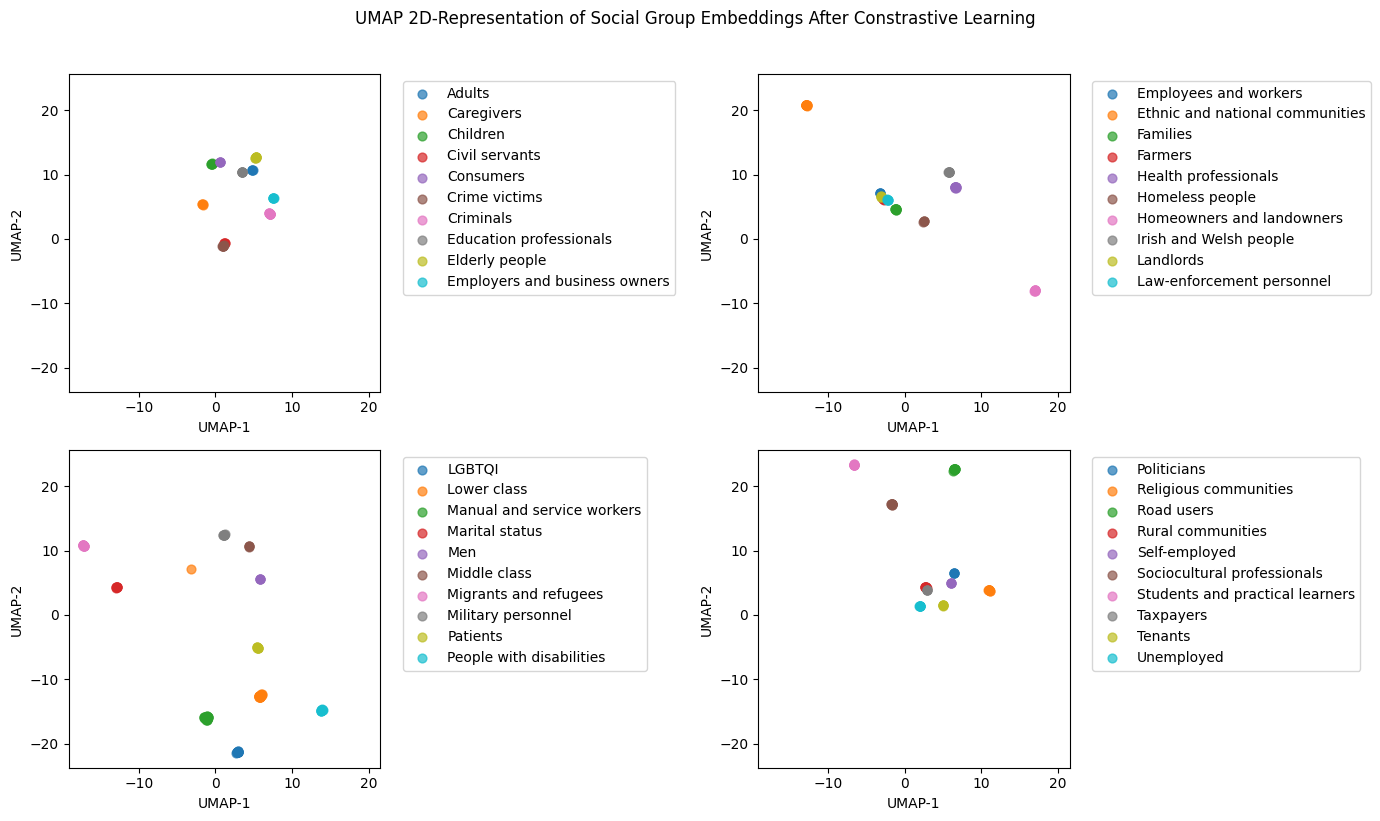

In [9]:
# create a fresh reducer and apply finetuned embeddings to it
reducer = umap.UMAP(n_components=2)
emb_2d = reducer.fit_transform(dictionary_embeddings)

# get axis ranges
x_min, x_max = emb_2d[:, 0].min(), emb_2d[:, 0].max()
y_min, y_max = emb_2d[:, 1].min(), emb_2d[:, 1].max()
pad = 0.05
x_range = x_max - x_min
y_range = y_max - y_min

# get all unique categories as a list and the total number of categories
categories = list(cat2id.keys())
num_classes = len(categories)

# define the category ranges
groups = [
    range(0, 10),
    range(10, 20),
    range(20, 30),
    range(30, 40)
]

# draw the plot
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, group in zip(axes, groups):
    for c in group:
        if c >= num_classes:
            continue
        idx = np.where(dictionary_labels_np == c)[0]
        if len(idx) == 0:
            continue
        ax.scatter(
            emb_2d[idx, 0],
            emb_2d[idx, 1],
            label=categories[c],
            alpha=0.7,
            s=40
        )
    ax.set_xlim(x_min - pad * x_range, x_max + pad * x_range)
    ax.set_ylim(y_min - pad * y_range, y_max + pad * y_range)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

fig.suptitle("UMAP 2D-Representation of Social Group Embeddings After Constrastive Learning", y=1.02)
plt.tight_layout()
plt.show()

## **Evaluate Cluster Quality of Dictionary Entries**

In [10]:
# cluster embeddings with DBSCAN and get silhouette score
X = dictionary_embeddings.numpy()

dbscan_model = DBSCAN(
    eps=0.3,
    min_samples=3,
    metric="euclidean"
)
pred_labels = dbscan_model.fit_predict(X)
dbscan_df = pd.DataFrame(
    {"mention": mention_list,
     "dbscan_cluster": pred_labels}
)
silhouette_score(X, pred_labels)

0.9198240041732788

Original number of categories: 45
Best k by BIC: 45


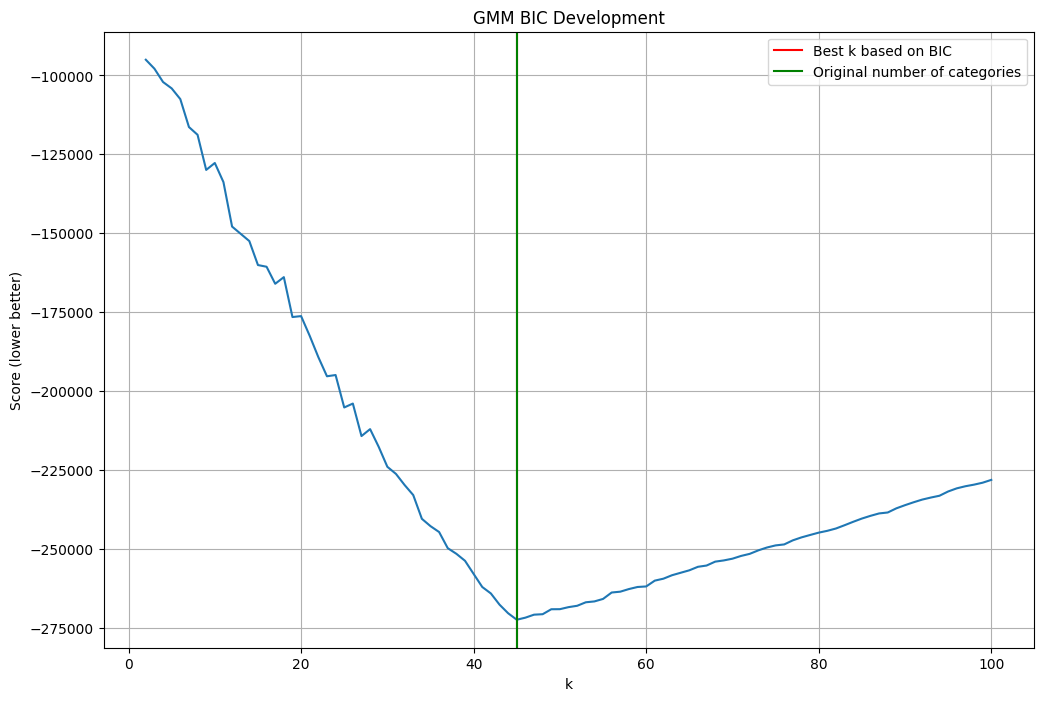

In [11]:
# create range of GMMs with increasing k and store the BIC
ks = range(2, 101)
bics = []
cov_type = 'diag'
for k in ks:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type=cov_type,
        random_state=7,
        n_init=5,
        reg_covar=1e-6,
        max_iter=500
    )
    gmm.fit(X)
    bics.append(gmm.bic(X))

# find the optimal bic
bics = np.array(bics)
best_idx = bics.argmin()
best_k = ks[best_idx]
print("Original number of categories: 45")
print("Best k by BIC:", best_k)

# plot development
plt.figure(figsize=(12,8))
plt.plot(list(ks), bics)
plt.axvline(best_k, color="red", label="Best k based on BIC")
plt.axvline(45, color="green", label="Original number of categories")
plt.xlabel('k')
plt.ylabel('Score (lower better)')
plt.title(f'GMM BIC Development')
plt.legend()
plt.grid(True)
plt.show()

Original number of categories: 45
Best k by silhouette score: 45


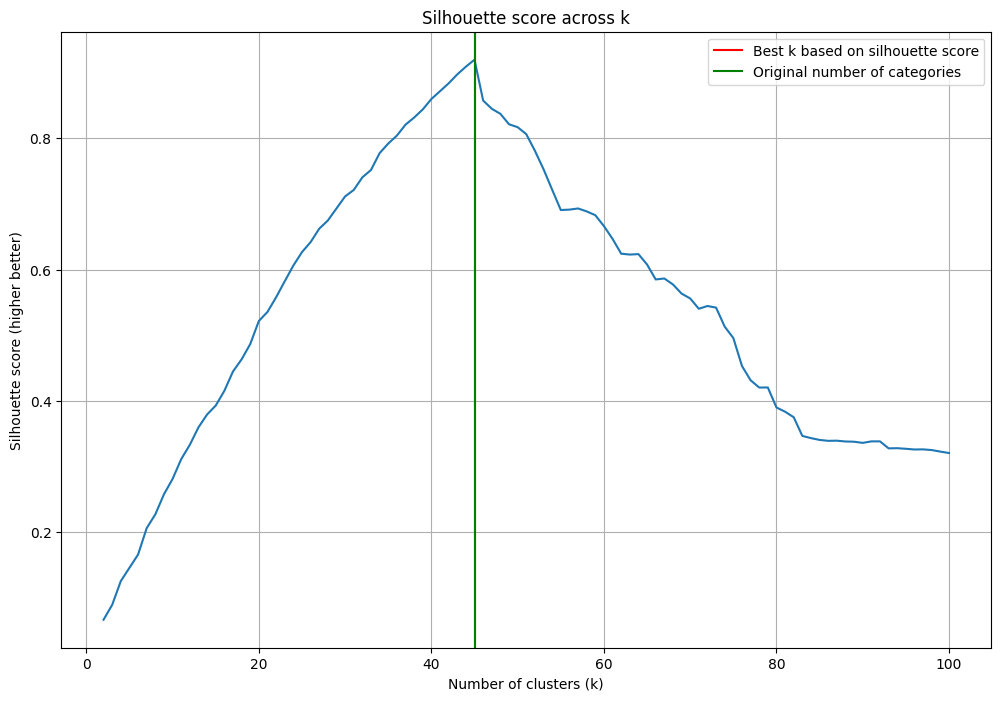

In [13]:
# create range of k-means models with increasing k and store the silhouette score 
ks = range(2, 101)

silhouette_scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=7)
    pred_labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, pred_labels))

silhouette_scores_array = np.array(silhouette_scores)

best_idx = silhouette_scores_array.argmax()
best_k = ks[best_idx]
best_score = silhouette_scores_array[best_idx]

print("Original number of categories: 45")
print(f"Best k by silhouette score: {best_k}")

plt.figure(figsize=(12, 8))
plt.plot(list(ks), silhouette_scores_array)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score (higher better)")
plt.title("Silhouette score across k")
plt.grid(True)
plt.axvline(best_k, color="red", label="Best k based on silhouette score")
plt.axvline(45, color="green", label="Original number of categories")
plt.legend()
plt.show()

In [14]:
# create k-means model with optimal k
kmeans = KMeans(n_clusters=best_k, random_state=7)
pred_labels = kmeans.fit_predict(X)
groups_dict_long["cluster"] = pred_labels

# compute external validation metrics based on ground truth labels
nmi = normalized_mutual_info_score(
    groups_dict_long["category"],
    groups_dict_long["cluster"]
)
ari = adjusted_rand_score(
    groups_dict_long["category"],
    groups_dict_long["cluster"]
)

# print all metrics for the dictionary evaluation
print(f"Silhouette score: {best_score:.4f}")
print(f"NMI score: {nmi:.4f}")
print(f"ARI score: {ari:.4f}")

Silhouette score: 0.9198
NMI score: 0.9950
ARI score: 0.9863


## **Apply Model to Annotation Data**

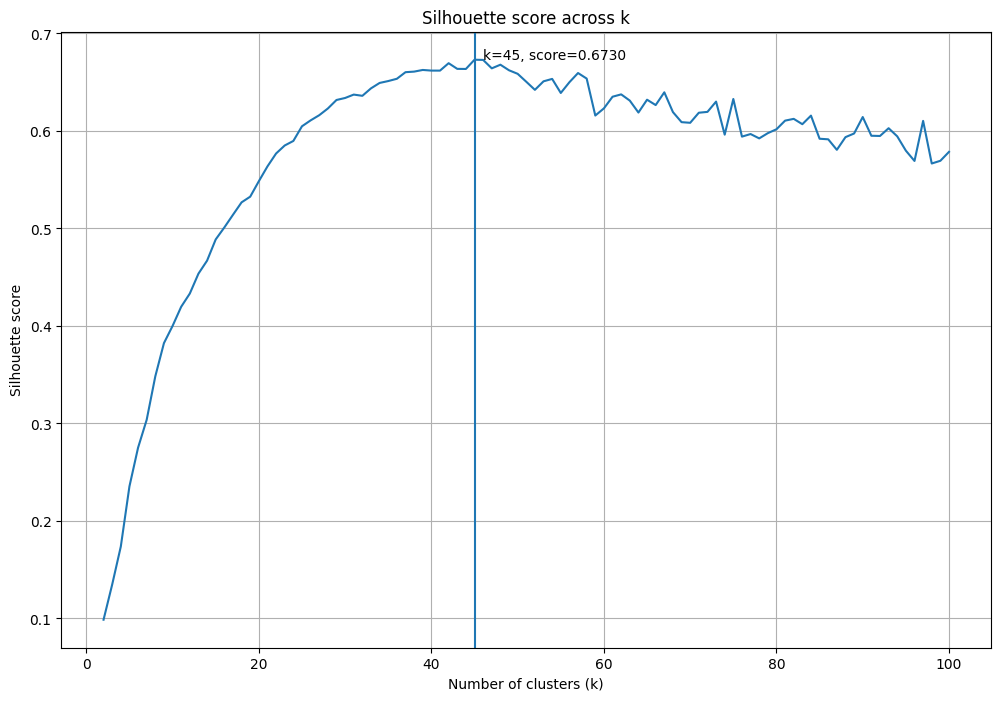

In [61]:
# import all annotations
with open("../01_data/classification/annotations/annotations_no_augmentations.json") as f:
    all_annotations = json.load(f)

# get all individual group mentions and create df
annotation_mentions = [ann["text"] for task in all_annotations for ann in task["annotations"] if task["annotations"]]
annotations_df = pd.DataFrame({"mention": annotation_mentions, "category": "Unknown"})

# load the original groups dictionary
groups_dict_original = pd.read_csv("../01_data/classification/dictionary/groups_dictionary.csv")

# create lookup regex and apply to the df
category_regex, group_lookup = create_category_regex(groups_dict_original)
annotations_df[["in_dictionary", "category"]] = annotations_df["mention"].apply(lambda x: pd.Series(match_dictionary(category_regex, group_lookup, x)))

# pass all mentions through the model
annotation_embeddings = get_mask_embedding(model, annotation_mentions, tokenizer, device)

# get the annotation embeddings as a numpy array
X = annotation_embeddings.numpy()

# set range of ks to evaluate
num_potential_clusters = 100
ks = list(range(2, num_potential_clusters+1))

# empty lists to store internal and external validation metrics
silhouette_scores = []
nmi_scores = []
ari_scores = []

# get mask for indicating which terms appear in dictionary
dict_mask = annotations_df["in_dictionary"].values
# get all categories for dictionary terms
dict_categories = annotations_df.loc[dict_mask, "category"].values

# loop over k
for k in ks:
    kmeans = KMeans(
        n_clusters=k,
        random_state=7,
        n_init=10,
        max_iter=300
    )

    # fit and predict cluster for all embeddings
    pred_labels = kmeans.fit_predict(X)

    # compute scores
    sil_score = silhouette_score(X, pred_labels)
    nmi = normalized_mutual_info_score(
        dict_categories,
        pred_labels[dict_mask]
    )
    ari = adjusted_rand_score(
        dict_categories,
        pred_labels[dict_mask]
    )

    # append all scores to their lists
    silhouette_scores.append(sil_score)
    nmi_scores.append(nmi)
    ari_scores.append(ari)

# find best silhouette score
silhouette_scores_array = np.array(silhouette_scores)
best_idx = silhouette_scores_array.argmax()
best_k = ks[best_idx]
best_score = silhouette_scores[best_idx]

# plot development of silhouette scores
plt.figure(figsize=(12, 8))
plt.plot(ks, silhouette_scores)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score across k")
plt.grid(True)
plt.axvline(best_k)
plt.annotate(
    f"k={best_k}, score={best_score:.4f}",
    xy=(best_k, best_score),
    xytext=(best_k + 1, best_score),
)
plt.show()

In [81]:
def find_opt_k(ks, silhouette_scores, nmi_scores, tolerance):
    silhouette_scores_array = np.array(silhouette_scores)
    silhouette_threshold = tolerance * silhouette_scores_array.max()
    candidate_ks = [k for k, s in zip(ks, silhouette_scores_array) if s >= silhouette_threshold]
    nmi_dict = dict(zip(ks, nmi_scores))
    best_k = max(candidate_ks, key=lambda k: nmi_dict[k])
    sil_dict = dict(zip(ks, silhouette_scores))
    resp_silscore = sil_dict[best_k]
    return best_k, resp_silscore

def find_opt_k_alt(ks, silhouette_scores, nmi_scores, tolerance):
    silhouette_scores_array = np.array(silhouette_scores)
    silhouette_threshold = tolerance * silhouette_scores_array.max()
    candidate_ks = [k for k, s in zip(ks, silhouette_scores_array) if s >= silhouette_threshold]
    nmi_dict = dict(zip(ks, nmi_scores))
    candidate_nmis = np.array([nmi_dict[k] for k in candidate_ks])
    nmi_threshold = 0.95 * candidate_nmis.max()
    candidate_ks = [
        k for k in candidate_ks
        if nmi_dict[k] >= nmi_threshold
    ]
    sil_dict = dict(zip(ks, silhouette_scores))
    best_k = max(candidate_ks, key=lambda k: sil_dict[k])
    resp_silscore = sil_dict[best_k]
    return best_k, resp_silscore

best_k, silscore = find_opt_k(ks, silhouette_scores, nmi_scores, 0.95)
print(f"Best k based on silhouette score and NMI: {best_k}")

# run model with optimal k
kmeans = KMeans(n_clusters=best_k, random_state=7)
labels = kmeans.fit_predict(X)
annotations_df["kmeans_cluster"] = labels

# reduce df to only the dictionary matches
annotations_df_dict = annotations_df[annotations_df["in_dictionary"] == True]

# create contingency table
contingency = pd.crosstab(
    annotations_df_dict["category"], annotations_df_dict["kmeans_cluster"]
)

# calculate purity and homogeneity
category_purity = contingency.max(axis=1) / contingency.sum(axis=1)
cluster_homogeneity = contingency.max(axis=0) / contingency.sum(axis=0)
mean_purity = np.mean(category_purity)

# calculate nmi and ari for the kmeans clustering
nmi_kmeans = normalized_mutual_info_score(
    annotations_df_dict["category"],
    annotations_df_dict["kmeans_cluster"]
)
ari_kmeans = adjusted_rand_score(
    annotations_df_dict["category"],
    annotations_df_dict["kmeans_cluster"]
)

print("\nValidation metrics for k-means clustering")
print("-"*50)
print(f"Silhouette score: {silscore:.4f}")
print(f"Mean purity: {mean_purity:.4f}")
print(f"NMI score: {nmi_kmeans:.4f}")
print(f"ARI score: {ari_kmeans:.4f}")

# run dbscan clustering
dbscan_model = DBSCAN(
    eps=0.5,
    min_samples=3,
    metric="euclidean"
)
dbscan_labels = dbscan_model.fit_predict(X)

# get copy of the df for dbscan evaluation
dbscan_df = annotations_df.copy()
dbscan_df["dbscan_cluster"] = dbscan_labels

# get noise mask
non_noise_mask = dbscan_df["dbscan_cluster"] != -1

# print number of noise rows
print(f"\nSize of the noise cluster: {sum(non_noise_mask == False)}")
print(f"Overall data points: {len(dbscan_df)}")

# get predicted non-noise clusters
non_noise_clusters = dbscan_df.loc[non_noise_mask, "dbscan_cluster"].values

# compute silhouette score
silscore_dbscan = silhouette_score(X[non_noise_mask], non_noise_clusters)

# remove noise rows
dbscan_df = dbscan_df[non_noise_mask]

# get only the rows with dictionary terms
dbscan_df_dict = dbscan_df[dbscan_df["in_dictionary"] == True]

# calculate nmi and ari for the dbscan clustering
nmi_dbscan = normalized_mutual_info_score(
    dbscan_df_dict["category"],
    dbscan_df_dict["dbscan_cluster"]
)
ari_dbscan = adjusted_rand_score(
    dbscan_df_dict["category"],
    dbscan_df_dict["dbscan_cluster"]
)

print("\nValidation metrics for DBSCAN clustering")
print("-"*50)
print(f"Silhouette score: {silscore_dbscan:.4f}")
print(f"NMI score (after noise removal): {nmi_dbscan:.4f}")
print(f"ARI score (after noise removal): {ari_dbscan:.4f}")

Best k based on silhouette score and NMI: 49

Validation metrics for k-means clustering
--------------------------------------------------
Silhouette score: 0.6622
Mean purity: 0.9163
NMI score: 0.8916
ARI score: 0.8433

Size of the noise cluster: 343
Overall data points: 3604

Validation metrics for DBSCAN clustering
--------------------------------------------------
Silhouette score: 0.6462
NMI score (after noise removal): 0.9207
ARI score (after noise removal): 0.8926


In [85]:
# inspect the noise cluster

# run dbscan clustering
dbscan_model = DBSCAN(
    eps=0.5,
    min_samples=3,
    metric="euclidean"
)
dbscan_labels = dbscan_model.fit_predict(X)

# get copy of the df for dbscan evaluation
dbscan_df = annotations_df.copy()
dbscan_df["dbscan_cluster"] = dbscan_labels

noise_cluster_mentions = dbscan_df[dbscan_df["dbscan_cluster"] == -1]["mention"]

for idx in range(30):
    print(noise_cluster_mentions.iloc[idx])

neighbours
Vulnerable young people
child sex slaves
those who fail in their responsibilities
tenants who are active farmers
an office holder
people in Mali who need our support
political activists
skilled workers
all those whose jobs depend on visiting people's homes
householders and businesses in Exeter and throughout the south-west
those from ethnic minorities
former Remploy employees who find themselves in part-time or full-time work
constituents in Ashford
power engineers
People in Derbyshire
colleagues who lost their lives in the Province
managers in the National Offender Management Service
a conscientious employee
every English household
Harland and Wolff workers in Northern Ireland
Parents seeking a diagnosis of autism
the rebels in Syria
people caught by the new Magnitsky legislation in this country
households found to be homeless but not in priority need
Ethnic minorities
urban poor
British charity workers
self-employed tax credit claimants
seasonal workers


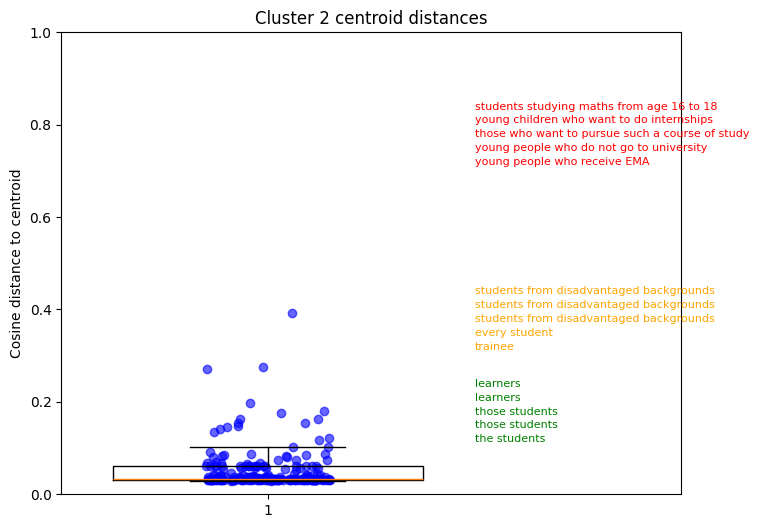

In [46]:
# get cluster centroids
centroids = kmeans.cluster_centers_

# cosine distance of each point to its assigned centroid
cos_sim = np.sum(X * centroids[labels], axis=1)
cos_dist = 1 - cos_sim
annotations_df["distance_to_centroid"] = cos_dist

def create_boxplot_with_mentions(cluster_df, cluster_id, top_n=5, point_jitter=0.03, vertical_spacing=0.03):
    """
    Boxplot with mentions displayed in fixed vertical bands relative to the figure:
    - closest (green) at bottom
    - median (orange) in middle
    - farthest (red) at top
    Data points are jittered horizontally and plotted at their real distances.
    """
    cluster_data = cluster_df[cluster_df["cluster"] == cluster_id]
    distances = cluster_data["distance_to_centroid"].values
    mentions = cluster_data["mention"].values

    # Sort indices
    sorted_idx = np.argsort(distances)
    closest_idx = sorted_idx[:top_n]
    median_idx = sorted_idx[len(sorted_idx)//2 - top_n//2 : len(sorted_idx)//2 + top_n//2 + 1]
    farthest_idx = sorted_idx[-top_n:]

    categories = {
        'closest': (closest_idx, 'green'),
        'median': (median_idx, 'orange'),
        'farthest': (farthest_idx, 'red')
    }

    fig, ax = plt.subplots(figsize=(8,6))
    x_base = 1  # base for boxplot and data points

    ax.boxplot(distances, vert=True, showfliers=False)

    jittered_x = x_base + np.random.uniform(-point_jitter, point_jitter, size=len(distances))
    ax.scatter(jittered_x, distances, color='blue', alpha=0.6)

    y_min, y_max = distances.min(), distances.max()
    band_positions = {
        'closest': 0.25,   # bottom
        'median': 0.45,    # middle above boxplot
        'farthest': 0.85   # top
    }

    for cat_name, (idxs, color) in categories.items():
        y_start = band_positions[cat_name]
        for i, idx in enumerate(idxs):
            y_pos = y_start - i*vertical_spacing
            ax.text(1.1, y_pos, mentions[idx], fontsize=8, color=color,
                    verticalalignment='top', horizontalalignment='left')

    ax.set_xlim(0.9, 1.2)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Cosine distance to centroid")
    ax.set_title(f"Cluster {cluster_id} centroid distances")
    plt.show()

    closest = mentions[closest_idx]
    median = mentions[median_idx]
    farthest = mentions[farthest_idx]
    return closest, median, farthest

closest_mentions, median_mentions, farthest_mentions = create_boxplot_with_mentions(annotations_df, 2)

In [47]:
def plot_cluster_boxplot_interactive(cluster_df, clusters, cluster_col='cluster', distance_col='distance_to_centroid', mention_col='mention'):
    cluster_df = cluster_df[cluster_df[cluster_col].isin(clusters)]
    cluster_ids = sorted(cluster_df[cluster_col].unique())
    colors = ['rgba(93, 164, 214, 0.5)', 'rgba(255, 144, 14, 0.5)', 'rgba(44, 160, 101, 0.5)',
              'rgba(255, 65, 54, 0.5)', 'rgba(207, 114, 255, 0.5)', 'rgba(127, 96, 0, 0.5)']
    
    # repeat colors if more clusters than colors
    colors = (colors * ((len(cluster_ids) // len(colors)) + 1))[:len(cluster_ids)]
    
    fig = go.Figure(layout=dict(width=800, height=600))
    
    for cid, color in zip(cluster_ids, colors):
        cluster_data = cluster_df[cluster_df[cluster_col] == cid]
        y_values = cluster_data[distance_col].values
        hover_texts = cluster_data[mention_col].values
        
        fig.add_trace(go.Box(
            y=y_values,
            name=f'Cluster {cid}',
            boxpoints='all',
            jitter=0.3,
            whiskerwidth=0.2,
            fillcolor=color,
            marker_size=3,
            line_width=1,
            text=hover_texts,
            hoverinfo='text+y'
        ))
    
    fig.update_layout(
        title=dict(
            text="Clustered Social Group Mentions with Cosine Distance to Centroid",
            x=0.5
        ),
        yaxis=dict(
            autorange=True,
            showgrid=True,
            zeroline=True,
            gridcolor='rgb(255, 255, 255)',
            gridwidth=1,
            zerolinecolor='rgb(255, 255, 255)',
            zerolinewidth=2,
            title="Cosine distance to centroid"
        ),
        paper_bgcolor='rgb(243, 243, 243)',
        plot_bgcolor='rgb(243, 243, 243)',
        margin=dict(l=40, r=30, t=80, b=100),
        showlegend=False
    )
    
    fig.show()

plot_cluster_boxplot_interactive(annotations_df, range(0, 5))

## **Apply Concept to the Main Data**

In [48]:
main_speech_df = pd.read_csv(
    "../01_data/empirical_analysis/main_speech_datasets/researchperiod_sentencelevel_socialgroups_stances.csv",
    parse_dates=["date", "birth_date"],
    dtype={
        "days_until_election": "int64",
        "agenda": "string",
        "text": "string",
        "sentence": "string",
        "speech_id": "int64",
        "speechnumber": "int64",
        "speaker": "string",
        "party": "category",
        "chair": "boolean",
        "age": "int64",
        "gender": "category",
        "vulnerability": "float64",
        "backbencher": "boolean",
        "constituency_name": "string",
        "ons_id": "string",
        "under_30": "float64",
        "over_65": "float64",
    },
    converters={
        "sg_spans": ast.literal_eval,
        "stances": ast.literal_eval,
    }
)

# reduce df to all speeches given during parliamentary question debates
question_df = main_speech_df[main_speech_df["agenda"].str.contains("question", case=False, na=False)].copy()

# get all detected social group mentions as a df, keep the row id to be able to later match back
question_df_long = question_df.loc[:, ["sg_spans"]].explode("sg_spans").dropna().reset_index(names="row_id")

# find dictionary matches and assign the group category
question_df_long[["in_dictionary", "category"]] = question_df_long["sg_spans"].apply(lambda x: pd.Series(match_dictionary(category_regex, group_lookup, x)))

# pass all mentions through the model
question_embeddings = get_mask_embedding(model, question_df_long["sg_spans"].tolist(), tokenizer, device)

In [51]:
# since not feasible to tune k with silhouette score just try out reasonable k

# turn to numpy array and run k means
X = question_embeddings.numpy()
kmeans = KMeans(n_clusters=50, random_state=7)

# fit model, predict labels and assign to df
labels = kmeans.fit_predict(X)
question_df_long["cluster"] = labels

# compute silhouette score for the overall clustering
silscore = silhouette_score(X, labels)

# reduce to the dictionary terms and compute nmi and ari
question_df_long_dict = question_df_long[question_df_long["in_dictionary"] == True]
nmi = normalized_mutual_info_score(
    question_df_long_dict["category"],
    question_df_long_dict["cluster"]
)
ari = adjusted_rand_score(
    question_df_long_dict["category"],
    question_df_long_dict["cluster"]
)

# print metrics
print(f"Silhouette score: {silscore}")
print(f"NMI score: {nmi}")
print(f"ARI score: {ari}")

# get cluster centroids
centroids = kmeans.cluster_centers_

# cosine distance of each point to its assigned centroid
cos_sim = np.sum(X * centroids[labels], axis=1)
cos_dist = 1 - cos_sim

# assign distances to the df
question_df_long["distance_to_centroid"] = cos_dist

Silhouette score: 0.5330466032028198
NMI score: 0.8888418617646017
ARI score: 0.8954674244511466


In [59]:
# plot some interactive cluster boxplots
plot_cluster_boxplot_interactive(question_df_long, range(5, 10), mention_col="sg_spans")